###Mount Google Drive

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###Import necessary libraries

In [14]:
import os
import numpy as np
import nibabel as nib
import cv2
import glob

In [3]:
# ================= CONFIGURATION =================
# Path to the BraTS dataset folder
# Structure: ./BraTS-Africa/95_Glioma/[SubjectID]/[files]

DATA_ROOT = '/content/drive/My Drive/Computer Vision Project/datasets/BraTS-Africa/95_Glioma'
OUTPUT_ROOT = '/content/drive/My Drive/Computer Vision Project/datasets/braTS_africa_test/glioma'

# How many patients to process
NUM_PATIENTS = 95

# Slices to extract per patient
SLICES_PER_PATIENT = 5

# Image settings
IMG_SIZE = (224, 224)
# =================================================

In [15]:
def normalize_slice(slice_data):
    """
    Normalizes MRI intensity to 0-255 (uint8) with outlier clipping.
    """
    p99 = np.percentile(slice_data, 99)
    slice_data = np.clip(slice_data, 0, p99)

    img_min = slice_data.min()
    img_max = slice_data.max()

    if img_max - img_min == 0:
        return slice_data.astype(np.uint8)

    normalized = (slice_data - img_min) / (img_max - img_min)
    return (normalized * 255).astype(np.uint8)

def process_gliomas():
    os.makedirs(OUTPUT_ROOT, exist_ok=True)

    # 1. Get Patient List
    patient_dirs = sorted([d for d in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, d))])

    selected_patients = patient_dirs[:NUM_PATIENTS]
    print(f"Selecting first {len(selected_patients)} patients from {len(patient_dirs)} total.")

    total_images = 0

    for pat_id in selected_patients:
        pat_path = os.path.join(DATA_ROOT, pat_id)

        # --- THE FIX IS HERE ---
        # We construct the filename using the patient ID folder name
        t1c_filename = f"{pat_id}-t1c.nii.gz"
        seg_filename = f"{pat_id}-seg.nii.gz"

        t1c_path = os.path.join(pat_path, t1c_filename)
        seg_path = os.path.join(pat_path, seg_filename)

        if not os.path.exists(t1c_path) or not os.path.exists(seg_path):
            print(f"Skipping {pat_id}: Files missing.\n  Expected: {t1c_path}")
            continue

        try:
            # 3. Load 3D Volumes
            t1c_vol = nib.load(t1c_path).get_fdata()
            seg_vol = nib.load(seg_path).get_fdata()
        except Exception as e:
            print(f"Error loading {pat_id}: {e}")
            continue

        # 4. Find the 'Best' Slices (largest tumor area)
        slice_scores = []
        depth = seg_vol.shape[2]

        for z in range(depth):
            tumor_area = np.sum(seg_vol[:, :, z] > 0)
            if tumor_area > 0:
                slice_scores.append((z, tumor_area))

        slice_scores.sort(key=lambda x: x[1], reverse=True)
        top_slices = slice_scores[:SLICES_PER_PATIENT]

        if not top_slices:
            print(f"No tumor mask found for {pat_id}")
            continue

        # 5. Extract, Resize, and Save
        for (z_index, area) in top_slices:
            img_slice = t1c_vol[:, :, z_index]

            # Rotate if needed (MRI scans often load sideways)
            img_slice = np.rot90(img_slice, k=1)

            img_norm = normalize_slice(img_slice)
            img_resized = cv2.resize(img_norm, IMG_SIZE, interpolation=cv2.INTER_CUBIC)

            filename = f"{pat_id}_slice{z_index}.png"
            cv2.imwrite(os.path.join(OUTPUT_ROOT, filename), img_resized)
            total_images += 1

        print(f"Processed {pat_id}: Saved {len(top_slices)} slices.")

    print(f"Done! Extracted {total_images} images to {OUTPUT_ROOT}")

if __name__ == "__main__":
    process_gliomas()

Selecting first 95 patients from 95 total.
Processed BraTS-SSA-00002-000: Saved 5 slices.
Processed BraTS-SSA-00007-000: Saved 5 slices.
Processed BraTS-SSA-00008-000: Saved 5 slices.
Processed BraTS-SSA-00010-000: Saved 5 slices.
Processed BraTS-SSA-00011-000: Saved 5 slices.
Processed BraTS-SSA-00012-000: Saved 5 slices.
Processed BraTS-SSA-00014-000: Saved 5 slices.
Processed BraTS-SSA-00015-000: Saved 5 slices.
Processed BraTS-SSA-00025-000: Saved 5 slices.
Processed BraTS-SSA-00026-000: Saved 5 slices.
Processed BraTS-SSA-00028-000: Saved 5 slices.
Processed BraTS-SSA-00037-000: Saved 5 slices.
Processed BraTS-SSA-00041-000: Saved 5 slices.
Processed BraTS-SSA-00044-000: Saved 5 slices.
Processed BraTS-SSA-00046-000: Saved 5 slices.
Processed BraTS-SSA-00047-000: Saved 5 slices.
Processed BraTS-SSA-00049-000: Saved 5 slices.
Processed BraTS-SSA-00050-000: Saved 5 slices.
Processed BraTS-SSA-00051-000: Saved 5 slices.
Processed BraTS-SSA-00055-000: Saved 5 slices.
Processed BraTS-S

In [16]:
!pip install nibabel
import os
import numpy as np
import nibabel as nib
import cv2
import matplotlib.pyplot as plt

# ================= CONFIGURATION =================
# 1. Input: Where your raw BraTS 3D files are (Change if different)
# Assuming typical BraTS structure: parent_folder/Patient_ID/files...
DATA_ROOT = '/content/drive/My Drive/Computer Vision Project/datasets/BraTS-Africa/95_Glioma'

# 2. Output: The NEW folder for T2 images
OUTPUT_ROOT = '/content/drive/My Drive/Computer Vision Project/datasets/braTS_africa_test/glioma_t2'

# 3. Settings
NUM_PATIENTS = 95
SLICES_PER_PATIENT = 5
IMG_SIZE = (224, 224)
# =================================================

def normalize_slice(slice_data):
    """
    Normalizes MRI intensity to 0-255 (uint8) with outlier clipping.
    This helps the tumor stand out against the background.
    """
    # Clip top 1% outliers (often scanner noise)
    p99 = np.percentile(slice_data, 99)
    slice_data = np.clip(slice_data, 0, p99)

    img_min = slice_data.min()
    img_max = slice_data.max()

    if img_max - img_min == 0:
        return slice_data.astype(np.uint8)

    # Min-Max Scaling to 0-255
    normalized = (slice_data - img_min) / (img_max - img_min)
    return (normalized * 255).astype(np.uint8)

def process_gliomas_t2():
    # Create the new output directory
    os.makedirs(OUTPUT_ROOT, exist_ok=True)
    print(f"📂 Created/Found output directory: {OUTPUT_ROOT}")

    # Get Patient List
    if not os.path.exists(DATA_ROOT):
        print(f"❌ Error: Data root not found at {DATA_ROOT}")
        return

    patient_dirs = sorted([d for d in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, d))])

    # Select subset
    if NUM_PATIENTS:
        selected_patients = patient_dirs[:NUM_PATIENTS]
    else:
        selected_patients = patient_dirs

    print(f"🚀 Processing {len(selected_patients)} patients looking for T2-weighted scans...")

    total_images = 0

    for pat_id in selected_patients:
        pat_path = os.path.join(DATA_ROOT, pat_id)

        # --- THE FIX: Smart Modality Search ---
        # We look for T2 first, then T2-FLAIR.
        # This matches the "bright tumor" look of your training data.
        possible_t2_files = [
            f"{pat_id}-t2w.nii.gz",  # Standard T2
            f"{pat_id}-t2.nii.gz",   # Alternative T2
            f"{pat_id}-t2f.nii.gz",  # T2-FLAIR (also very good)
            f"{pat_id}-fla.nii.gz"   # FLAIR alternative
        ]

        t2_path = None
        found_modality = ""

        for fname in possible_t2_files:
            check_path = os.path.join(pat_path, fname)
            if os.path.exists(check_path):
                t2_path = check_path
                found_modality = fname
                break

        # Always need the segmentation mask to find the tumor
        seg_filename = f"{pat_id}-seg.nii.gz"
        seg_path = os.path.join(pat_path, seg_filename)

        if t2_path is None or not os.path.exists(seg_path):
            print(f"⚠️ Skipping {pat_id}: T2 or Seg file missing.")
            continue

        try:
            # Load 3D Volumes
            t2_vol = nib.load(t2_path).get_fdata()
            seg_vol = nib.load(seg_path).get_fdata()
        except Exception as e:
            print(f"❌ Error loading {pat_id}: {e}")
            continue

        # Find the 'Best' Slices (largest tumor area)
        slice_scores = []
        depth = seg_vol.shape[2]

        for z in range(depth):
            # We look for the mask (labels 1, 2, or 4 usually)
            tumor_area = np.sum(seg_vol[:, :, z] > 0)
            if tumor_area > 0:
                slice_scores.append((z, tumor_area))

        # Sort by tumor size (biggest first)
        slice_scores.sort(key=lambda x: x[1], reverse=True)
        top_slices = slice_scores[:SLICES_PER_PATIENT]

        if not top_slices:
            print(f"⚠️ No tumor mask found in segmentation for {pat_id}")
            continue

        # Extract, Resize, and Save
        for (z_index, area) in top_slices:
            img_slice = t2_vol[:, :, z_index]

            # Rotate if needed (MRI scans often load sideways in NIfTI)
            img_slice = np.rot90(img_slice, k=1)

            # Normalize specifically for T2 contrast
            img_norm = normalize_slice(img_slice)

            # Resize to model input size
            img_resized = cv2.resize(img_norm, IMG_SIZE, interpolation=cv2.INTER_CUBIC)

            # Save to the NEW T2 folder
            filename = f"{pat_id}_slice{z_index}_t2.png"
            cv2.imwrite(os.path.join(OUTPUT_ROOT, filename), img_resized)
            total_images += 1

        print(f"✅ Processed {pat_id} ({found_modality}): Saved {len(top_slices)} slices.")

    print(f"\n🎉 DONE! Extracted {total_images} T2 images to:\n{OUTPUT_ROOT}")

if __name__ == "__main__":
    process_gliomas_t2()

📂 Created/Found output directory: /content/drive/My Drive/Computer Vision Project/datasets/braTS_africa_test/glioma_t2
🚀 Processing 95 patients looking for T2-weighted scans...
✅ Processed BraTS-SSA-00002-000 (BraTS-SSA-00002-000-t2w.nii.gz): Saved 5 slices.
✅ Processed BraTS-SSA-00007-000 (BraTS-SSA-00007-000-t2w.nii.gz): Saved 5 slices.
✅ Processed BraTS-SSA-00008-000 (BraTS-SSA-00008-000-t2w.nii.gz): Saved 5 slices.
✅ Processed BraTS-SSA-00010-000 (BraTS-SSA-00010-000-t2w.nii.gz): Saved 5 slices.
✅ Processed BraTS-SSA-00011-000 (BraTS-SSA-00011-000-t2w.nii.gz): Saved 5 slices.
✅ Processed BraTS-SSA-00012-000 (BraTS-SSA-00012-000-t2w.nii.gz): Saved 5 slices.
✅ Processed BraTS-SSA-00014-000 (BraTS-SSA-00014-000-t2w.nii.gz): Saved 5 slices.
✅ Processed BraTS-SSA-00015-000 (BraTS-SSA-00015-000-t2w.nii.gz): Saved 5 slices.
✅ Processed BraTS-SSA-00025-000 (BraTS-SSA-00025-000-t2w.nii.gz): Saved 5 slices.
✅ Processed BraTS-SSA-00026-000 (BraTS-SSA-00026-000-t2w.nii.gz): Saved 5 slices.
✅ P

In [20]:
import os

folder_path = '/content/drive/My Drive/Computer Vision Project/datasets/braTS_africa_test/glioma_t2'

if os.path.exists(folder_path):
    file_count = len([f for f in os.listdir(folder_path) if f.endswith('.png')])
    print(f"✅ Found {file_count} images in '{folder_path}'")

    if file_count == 475:
        print("🎉 Perfect! You have exactly 95 patients × 5 slices.")
    else:
        print(f"⚠️ Warning: Expected 475 images, but found {file_count}.")
else:
    print(f"❌ Error: The folder '{folder_path}' does not exist.")

✅ Found 475 images in '/content/drive/My Drive/Computer Vision Project/datasets/braTS_africa_test/glioma_t2'
🎉 Perfect! You have exactly 95 patients × 5 slices.


In [18]:
import os

folder_path = '/content/drive/My Drive/Computer Vision Project/datasets/braTS_africa_test/glioma_t2'

files = os.listdir(folder_path)
t2_files = [f for f in files if f.endswith('_t2.png')]
t1c_files = [f for f in files if f.endswith('.png') and not f.endswith('_t2.png')]

print(f"Total T2 images: {len(t2_files)}")
print(f"Total T1c images: {len(t1c_files)}")

Total T2 images: 475
Total T1c images: 475


In [19]:
import os
import shutil

src_dir = '/content/drive/My Drive/Computer Vision Project/datasets/braTS_africa_test/glioma_t2'
dst_dir = '/content/drive/My Drive/Computer Vision Project/datasets/braTS_africa_test/glioma'

os.makedirs(dst_dir, exist_ok=True)

moved_count = 0
for f in os.listdir(src_dir):
    # Move T1c files (files that don't end in _t2.png)
    if f.endswith('.png') and not f.endswith('_t2.png'):
        shutil.move(os.path.join(src_dir, f), os.path.join(dst_dir, f))
        moved_count += 1

print(f"✅ Moved {moved_count} T1c slices to '{dst_dir}'")
print(f"Remaining T2 images in 'glioma_t2': {len(os.listdir(src_dir))}")

✅ Moved 475 T1c slices to '/content/drive/My Drive/Computer Vision Project/datasets/braTS_africa_test/glioma'
Remaining T2 images in 'glioma_t2': 475


In [4]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix

# Device Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ================= CONFIGURATION =================
SEEDS = [12, 23, 42, 2026]
SPLIT_RATIO = 0.40  # 40% patient-level validation holdout
NUM_EPOCHS = 25     # Set maximum training epochs per seed
BATCH_SIZE = 16

TUMOR_DIR = '/content/drive/My Drive/Computer Vision Project/datasets/braTS_africa_test/glioma'
HEALTHY_DIR = '/content/drive/My Drive/Computer Vision Project/datasets/axial'
WESTERN_DIR = '/content/drive/My Drive/Computer Vision Project/datasets/tumor' # Path to western train set

# Directory where generated .pth seed weights will be saved
SAVE_WEIGHTS_DIR = '/content/drive/My Drive/Computer Vision Project/checkpoints'
os.makedirs(SAVE_WEIGHTS_DIR, exist_ok=True)
# =================================================

class MRIDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

# Standard ImageNet Transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_patient_id(filename):
    base = os.path.basename(filename)
    if '_slice' in base:
        return base.split('_slice')[0]  # Extracts patient prefix
    return base.split('.')[0]

def load_brats_and_healthy():
    filepaths, labels, groups = [], [], []
    valid_exts = ('*.png', '*.jpg', '*.jpeg', '*.tif')

    if os.path.exists(TUMOR_DIR):
        for ext in valid_exts:
            for f in glob.glob(os.path.join(TUMOR_DIR, ext)):
                filepaths.append(f)
                labels.append(1)
                groups.append(extract_patient_id(f))

    if os.path.exists(HEALTHY_DIR):
        for ext in valid_exts:
            for f in glob.glob(os.path.join(HEALTHY_DIR, ext)):
                filepaths.append(f)
                labels.append(0)
                groups.append(extract_patient_id(f))

    return pd.DataFrame({'filepath': filepaths, 'label': labels, 'patient_id': groups})

# Paper-Exact Architecture (Section III.B)
class DINOv2Classifier(nn.Module):
    def __init__(self, backbone_model):
        super().__init__()
        self.backbone = backbone_model

        # Freeze backbone parameters
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Linear (384 -> 128) -> ReLU -> Dropout(0.5) -> Linear (128 -> 1) -> Sigmoid
        self.classifier = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        with torch.no_grad():
            features = self.backbone(x)
        return self.classifier(features).squeeze(-1)

def calculate_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return sensitivity, specificity

# ================= MULTI-SEED TRAINING & EVALUATION =================
df = load_brats_and_healthy()
results = []

for seed in SEEDS:
    print(f"\n--- Starting Pipeline for Seed {seed} ---")

    # 1. Patient-Level Group Split on both Tumor and Healthy cohorts
    brats_df = df[df['label'] == 1].copy()
    healthy_df = df[df['label'] == 0].copy()

    # Split Tumor cohort by patient ID
    gss_tumor = GroupShuffleSplit(n_splits=1, test_size=SPLIT_RATIO, random_state=seed)
    train_t_idx, val_t_idx = next(gss_tumor.split(brats_df, brats_df['label'], groups=brats_df['patient_id']))
    brats_train, brats_val = brats_df.iloc[train_t_idx], brats_df.iloc[val_t_idx]

    # Split Healthy control cohort by patient ID
    gss_healthy = GroupShuffleSplit(n_splits=1, test_size=SPLIT_RATIO, random_state=seed)
    train_h_idx, val_h_idx = next(gss_healthy.split(healthy_df, healthy_df['label'], groups=healthy_df['patient_id']))
    healthy_train, healthy_val = healthy_df.iloc[train_h_idx], healthy_df.iloc[val_h_idx]

    # Combine Tumor Train + Healthy Train for model training
    train_df = pd.concat([brats_train, healthy_train]).sample(frac=1, random_state=seed).reset_index(drop=True)

    # Load PyTorch DataLoaders
    train_dataset = MRIDataset(train_df['filepath'].values, train_df['label'].values, transform=train_transforms)
    val_brats_dataset = MRIDataset(brats_val['filepath'].values, brats_val['label'].values, transform=val_transforms)
    val_healthy_dataset = MRIDataset(healthy_val['filepath'].values, healthy_val['label'].values, transform=val_transforms)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_brats_loader = DataLoader(val_brats_dataset, batch_size=BATCH_SIZE, shuffle=False)
    val_healthy_loader = DataLoader(val_healthy_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # 2. Instantiate Architecture & Optimizer (Section III.B & III.C)
    backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
    model = DINOv2Classifier(backbone).to(device)

    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=7)

    # 3. Training Loop
    model.train()
    for epoch in range(NUM_EPOCHS):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_dataset)
        scheduler.step(epoch_loss)

    # 4. Save Trained Checkpoint
    checkpoint_path = os.path.join(SAVE_WEIGHTS_DIR, f"dinov2_seed_{seed}.pth")
    torch.save(model.state_dict(), checkpoint_path)
    print(f"Saved Seed {seed} model weights to: {checkpoint_path}")

    # 5. External Evaluation (Sensitivity & Specificity)
    model.eval()

    # Sensitivity (BraTS Holdout)
    brats_preds = []
    with torch.no_grad():
        for images, _ in val_brats_loader:
            outputs = model(images.to(device))
            brats_preds.extend((outputs >= 0.5).cpu().numpy().astype(int))

    # Specificity (Healthy Holdout Set)
    healthy_preds = []
    with torch.no_grad():
        for images, _ in val_healthy_loader:
            outputs = model(images.to(device))
            healthy_preds.extend((outputs >= 0.5).cpu().numpy().astype(int))

    y_true = np.concatenate([np.ones(len(brats_preds)), np.zeros(len(healthy_preds))])
    y_pred = np.concatenate([brats_preds, healthy_preds])

    sens, spec = calculate_metrics(y_true, y_pred)
    results.append({'Seed': seed, 'Sensitivity': sens, 'Specificity': spec})
    print(f"Seed {seed:4d} Complete | Sensitivity: {sens*100:.2f}% | Specificity: {spec*100:.2f}%")

# ================= TABLE I RESULTS =================
results_df = pd.DataFrame(results)

print("\n" + "="*50)
print("UPDATED TABLE I RESULTS (EXPANDED DATASET)")
print("="*50)
print(results_df.to_string(index=False))
print("-" * 50)
print(f"Sensitivity (Mean ± SD) : {results_df['Sensitivity'].mean()*100:.2f}% ± {results_df['Sensitivity'].std()*100:.2f}%")
print(f"Specificity (Mean ± SD) : {results_df['Specificity'].mean()*100:.2f}% ± {results_df['Specificity'].std()*100:.2f}%")

Using device: cuda

--- Starting Pipeline for Seed 12 ---


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Saved Seed 12 model weights to: /content/drive/My Drive/Computer Vision Project/checkpoints/dinov2_seed_12.pth
Seed   12 Complete | Sensitivity: 100.00% | Specificity: 100.00%

--- Starting Pipeline for Seed 23 ---


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Saved Seed 23 model weights to: /content/drive/My Drive/Computer Vision Project/checkpoints/dinov2_seed_23.pth
Seed   23 Complete | Sensitivity: 100.00% | Specificity: 100.00%

--- Starting Pipeline for Seed 42 ---


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Saved Seed 42 model weights to: /content/drive/My Drive/Computer Vision Project/checkpoints/dinov2_seed_42.pth
Seed   42 Complete | Sensitivity: 100.00% | Specificity: 100.00%

--- Starting Pipeline for Seed 2026 ---


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Saved Seed 2026 model weights to: /content/drive/My Drive/Computer Vision Project/checkpoints/dinov2_seed_2026.pth
Seed 2026 Complete | Sensitivity: 100.00% | Specificity: 90.00%

UPDATED TABLE I RESULTS (EXPANDED DATASET)
 Seed  Sensitivity  Specificity
   12          1.0          1.0
   23          1.0          1.0
   42          1.0          1.0
 2026          1.0          0.9
--------------------------------------------------
Sensitivity (Mean ± SD) : 100.00% ± 0.00%
Specificity (Mean ± SD) : 97.50% ± 5.00%


In [5]:
# Save Table I results directly to Google Drive
csv_save_path = os.path.join(SAVE_WEIGHTS_DIR, 'table_1_results.csv')
results_df.to_csv(csv_save_path, index=False)

print(f"✅ Table saved successfully to: {csv_save_path}")

✅ Table saved successfully to: /content/drive/My Drive/Computer Vision Project/checkpoints/table_1_results.csv


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


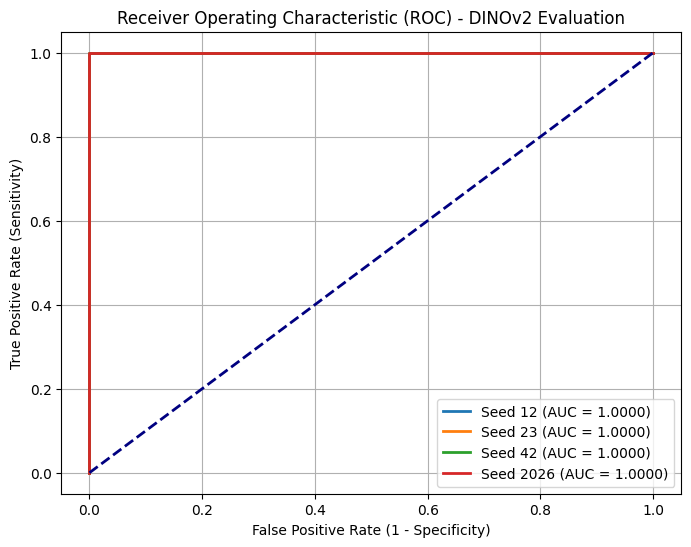

✅ ROC Curve plot saved to: /content/drive/My Drive/Computer Vision Project/checkpoints/roc_auc_curve.png


In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

# Evaluate probabilities across seed checkpoints
for seed in SEEDS:
    # Load model architecture & saved weights
    backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
    model = DINOv2Classifier(backbone).to(device)
    checkpoint_path = os.path.join(SAVE_WEIGHTS_DIR, f"dinov2_seed_{seed}.pth")
    model.load_state_dict(torch.load(checkpoint_path))
    model.eval()

    # Get raw sigmoid probabilities
    y_true_all, y_probs_all = [], []

    with torch.no_grad():
        for images, labels in val_brats_loader:
            outputs = model(images.to(device))
            y_probs_all.extend(outputs.cpu().numpy())
            y_true_all.extend(labels.numpy())

        for images, labels in val_healthy_loader:
            outputs = model(images.to(device))
            y_probs_all.extend(outputs.cpu().numpy())
            y_true_all.extend(labels.numpy())

    # Compute ROC Curve & AUC score
    fpr, tpr, _ = roc_curve(y_true_all, y_probs_all)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Seed {seed} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) - DINOv2 Evaluation')
plt.legend(loc="lower right")
plt.grid(True)

# Save ROC plot to Google Drive
plot_save_path = os.path.join(SAVE_WEIGHTS_DIR, 'roc_auc_curve.png')
plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ ROC Curve plot saved to: {plot_save_path}")